In [1]:
import torch
from torch.utils.data import DataLoader, Dataset
import zipfile
import math
import os
import json
from tqdm import tqdm

# Import your assignment files
from config import GPTConfig
from tokenizer import BPETokenizer
from model import GPT 

# ==========================================
# 0. DIRECTORY SETUP (KEEP ACTIVE)
# ==========================================
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)
print(f"Directory '{output_dir}' is ready for saving weights and stats.")

# ==========================================
# 1. SETUP: DEVICE, CONFIG, AND TOKENIZER (KEEP ACTIVE)
# ==========================================
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Running on device: {device}")

# Load Config & Enforce Teacher's Rule
config = GPTConfig.from_toml('config.toml')
assert config.block_size == 512, "ERROR: Teacher said DO NOT change block_size!"

# Load Tokenizer
tokenizer = BPETokenizer()
tokenizer.load('merges.json')
print("Tokenizer loaded successfully.")

# ==========================================
# 2. DATASET CLASS DEFINITION (KEEP ACTIVE)
# ==========================================
class TinyStoriesDataset(Dataset):
    def __init__(self, zip_path, file_name, tokenizer, block_size, max_stories):
        self.block_size = block_size
        print(f"Reading {file_name} from {zip_path} (Limiting to {max_stories} stories)...")
        
        tokens = []
        stories_processed = 0
        
        # Read the file line-by-line (story-by-story) instead of all at once
        with zipfile.ZipFile(zip_path, 'r') as z:
            with z.open(file_name) as f:
                for line in f:
                    if not line.strip():
                        continue  # Skip empty lines
                    
                    # Tokenize just this single story/line
                    token_ids = tokenizer._encode_chunk(line)
                    tokens.extend(token_ids)
                    
                    stories_processed += 1
                    
                    if stories_processed % 10000 == 0:
                        print(f"  ...Tokenized {stories_processed}/{max_stories} stories")
                        
                    if stories_processed >= max_stories:
                        break
                        
        self.tokens = torch.tensor(tokens, dtype=torch.long)
        print(f"✅ Loaded {len(self.tokens)} total tokens from {stories_processed} stories.")

    def __len__(self):
        return len(self.tokens) - self.block_size

    def __getitem__(self, idx):
        chunk = self.tokens[idx : idx + self.block_size + 1]
        x = chunk[:-1] 
        y = chunk[1:]  
        return x, y
    
    
# # Load datasets dynamically, capped to prevent timeout!
# train_dataset = TinyStoriesDataset('TinyStories_.zip', 'TinyStories_train.txt', tokenizer, config.block_size, max_stories=65000)
# val_dataset = TinyStoriesDataset('TinyStories_.zip', 'TinyStories_val.txt', tokenizer, config.block_size, max_stories=2000)

# # ==========================================
# # 3. HELPER FUNCTION FOR VALIDATION
# # ==========================================
# def estimate_loss(model, loader, eval_iters=10):
#     model.eval()
#     losses = torch.zeros(eval_iters)
#     with torch.no_grad():
#         for i, (X, Y) in enumerate(loader):
#             if i >= eval_iters: break
#             X, Y = X.to(device), Y.to(device)
#             logits, loss = model(X, targets=Y)
#             losses[i] = loss.item()
#     model.train()
#     return losses.mean().item()

# # ==========================================
# # 4. HYPERPARAMETER TRIALS LOOP WITH SAVING
# # ==========================================
# trials = [
#     {"name": "Trial_1_Baseline",         "lr": 3e-4, "batch_size": 32, "weight_decay": 0.1},
#     {"name": "Trial_2_Fast_Learner",     "lr": 1e-3, "batch_size": 32, "weight_decay": 0.1},
#     {"name": "Trial_3_High_Reg",         "lr": 5e-4, "batch_size": 16, "weight_decay": 0.2},
#     {"name": "Trial_4_Conservative",     "lr": 1e-4, "batch_size": 32, "weight_decay": 0.05},
#     {"name": "Trial_5_High_Throughput",  "lr": 5e-4, "batch_size": 64, "weight_decay": 0.1},
# ]

# max_iters = 2000     
# eval_interval = 250  

# # Dictionary to hold ALL stats for EVERY trial
# all_trials_stats = {}

# for trial in trials:
#     print(f"\n" + "="*50)
#     print(f"🚀 STARTING {trial['name']}")
#     print(f"Params: LR={trial['lr']}, Batch={trial['batch_size']}, WD={trial['weight_decay']}")
#     print("="*50)

#     train_loader = DataLoader(train_dataset, batch_size=trial['batch_size'], shuffle=True)
#     val_loader = DataLoader(val_dataset, batch_size=trial['batch_size'], shuffle=False)
#     train_iter = iter(train_loader)

#     model = GPT(config)
#     model.to(device)

#     optimizer = model.configure_optimizers(
#         learning_rate=trial['lr'], 
#         weight_decay=trial['weight_decay']
#     )

#     model.train()
    
#     best_val_loss = float('inf')
#     step_history = [] 
    
#     for step in range(max_iters):
#         try:
#             xb, yb = next(train_iter)
#         except StopIteration:
#             train_iter = iter(train_loader)
#             xb, yb = next(train_iter)
            
#         xb, yb = xb.to(device), yb.to(device)

#         logits, loss = model(xb, targets=yb)
        
#         optimizer.zero_grad(set_to_none=True)
#         loss.backward()
#         optimizer.step()

#         # Evaluate and record stats
#         if step % eval_interval == 0 or step == max_iters - 1:
#             val_loss = estimate_loss(model, val_loader)
#             train_loss_val = loss.item()
            
#             print(f"  Step {step:04d} | Train Loss: {train_loss_val:.4f} | Val Loss: {val_loss:.4f}")
            
#             step_history.append({
#                 "step": step,
#                 "train_loss": train_loss_val,
#                 "val_loss": val_loss
#             })
            
#             if val_loss < best_val_loss:
#                 best_val_loss = val_loss
#                 save_path = os.path.join(output_dir, f"{trial['name']}_best.pt")
#                 torch.save(model.state_dict(), save_path)
#                 print(f"  💾 -> Saved new best weights to {save_path}")

#     all_trials_stats[trial['name']] = {
#         "best_val_loss": best_val_loss,
#         "history": step_history
#     }
#     print(f"✅ Finished {trial['name']} - Best Val Loss: {best_val_loss:.4f}")

# # ==========================================
# # 5. FINAL RESULTS SUMMARY & STATS EXPORT
# # ==========================================
# print("\n" + "*"*50)
# print("🏆 HYPERPARAMETER TUNING RESULTS 🏆")
# print("*"*50)

# best_trial_name = min(all_trials_stats, key=lambda k: all_trials_stats[k]["best_val_loss"])

# for name, stats in all_trials_stats.items():
#     print(f"{name}: Best Validation Loss = {stats['best_val_loss']:.4f}")

# print(f"\n=> The best performing set was: {best_trial_name}")

# stats_file = os.path.join(output_dir, "all_tuning_stats.json")
# with open(stats_file, "w") as f:
#     json.dump(all_trials_stats, f, indent=4)
    
# print(f"📊 All step-by-step training statistics saved to {stats_file}")
# print("You are ready to use these stats for your PDF graphs!")

Directory 'output' is ready for saving weights and stats.
Running on device: cpu
Tokenizer loaded successfully.


In [ ]:
# ==========================================
# FINAL RUN: ARCHITECTURE COMPARISON (AUTO-SAVING)
# ==========================================
import torch.nn.functional as F
import copy
import json
import os

print("\n🚀 Starting Serious Architecture Training Run...")

# 1. Load or Create the Serious Dataset (200k stories)
train_pt = 'pretokenized_train_200k.pt'
val_pt = 'pretokenized_val_5k.pt'

if os.path.exists(train_pt) and os.path.exists(val_pt):
    print(f"📂 Found pre-tokenized files. Loading instantly...")
    train_tokens = torch.load(train_pt)
    val_tokens = torch.load(val_pt)
    
    # Create custom Dataset wrapper that just stores the pre-loaded tokens
    class PreTokenizedDataset(Dataset):
        def __init__(self, tokens, block_size):
            self.tokens = tokens
            self.block_size = block_size
        def __len__(self): return len(self.tokens) - self.block_size
        def __getitem__(self, idx):
            chunk = self.tokens[idx : idx + self.block_size + 1]
            return chunk[:-1], chunk[1:]
            
    train_dataset = PreTokenizedDataset(train_tokens, config.block_size)
    val_dataset = PreTokenizedDataset(val_tokens, config.block_size)
else:
    print(f"⚠️ No pre-tokenized files found. Running slow tokenization (only once)...")
    train_dataset = TinyStoriesDataset('TinyStories_.zip', 'TinyStories_train.txt', tokenizer, config.block_size, max_stories=200000)
    val_dataset = TinyStoriesDataset('TinyStories_.zip', 'TinyStories_val.txt', tokenizer, config.block_size, max_stories=5000)
    
    # Save for next time
    torch.save(train_dataset.tokens, train_pt)
    torch.save(val_dataset.tokens, val_pt)
    print(f"💾 Saved tokens to disk for future runs.")

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

# 2. Define the 4 Architectures
arch_configs = {}

# Arch 1: Baseline with 10% Dropout
c1 = GPTConfig.from_toml('config.toml')
c1.embd_pdrop = 0.1; c1.resid_pdrop = 0.1; c1.attn_pdrop = 0.1
arch_configs["Arch_1_Baseline"] = c1

# Arch 2: Deep & Narrow (More layers, smaller embeddings)
c2 = GPTConfig.from_toml('config.toml')
c2.n_layer = 8; c2.n_head = 4; c2.n_embd = 256
c2.embd_pdrop = 0.1; c2.resid_pdrop = 0.1; c2.attn_pdrop = 0.1
arch_configs["Arch_2_Deep_Narrow"] = c2

# Arch 3: Shallow & Wide (Fewer layers, massive embeddings)
c3 = GPTConfig.from_toml('config.toml')
c3.n_layer = 4; c3.n_head = 8; c3.n_embd = 512
c3.embd_pdrop = 0.1; c3.resid_pdrop = 0.1; c3.attn_pdrop = 0.1
arch_configs["Arch_3_Shallow_Wide"] = c3

# Arch 4: Heavy Regularization (30% Dropout)
c4 = GPTConfig.from_toml('config.toml')
c4.embd_pdrop = 0.3; c4.resid_pdrop = 0.3; c4.attn_pdrop = 0.3
arch_configs["Arch_4_High_Dropout"] = c4

# 3. Evaluation Function (Loss & Accuracy)
def estimate_loss_and_acc(model, loader, eval_iters=20):
    model.eval()
    losses, accs = torch.zeros(eval_iters), torch.zeros(eval_iters)
    with torch.no_grad():
        for i, (X, Y) in enumerate(loader):
            if i >= eval_iters: break
            X, Y = X.to(device), Y.to(device)
            logits, loss = model(X, targets=Y)
            
            preds = logits.argmax(dim=-1)
            acc = (preds == Y).float().mean()
            
            losses[i] = loss.item()
            accs[i] = acc.item()
    model.train()
    return losses.mean().item(), accs.mean().item()

# 4. Training Variables
max_iters = 5000       # 5000 steps per architecture is a very solid "serious" run
eval_interval = 500  
stats_file = os.path.join(output_dir, "architecture_comparison_stats.json")

# Load existing stats if the job was restarted, otherwise start fresh
if os.path.exists(stats_file):
    with open(stats_file, "r") as f:
        all_arch_stats = json.load(f)
else:
    all_arch_stats = {}

# 5. The Main Loop over Architectures
for arch_name, a_config in arch_configs.items():
    
    # Skip if we already finished this architecture in a previous crashed run
    if arch_name in all_arch_stats and len(all_arch_stats[arch_name]["step"]) >= (max_iters // eval_interval):
        print(f"⏭️ Skipping {arch_name}, already completed!")
        continue

    print(f"\n" + "="*50)
    print(f"🧠 BUILDING AND TRAINING: {arch_name}")
    print(f"Layers: {a_config.n_layer} | Heads: {a_config.n_head} | Embd: {a_config.n_embd} | Drop: {a_config.embd_pdrop}")
    print("="*50)

    # Initialize Model with the specific architecture
    model = GPT(a_config).to(device)
    
    # Winning parameters from hyperparameter tune
    optimizer = model.configure_optimizers(weight_decay=0.1, learning_rate=3e-4, betas=(0.9, 0.95))    
    train_iter = iter(train_loader)
    history = {"step": [], "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    accumulation_steps = 8  # 4 (batch size) * 8 = 32 (your original virtual batch size)
    optimizer.zero_grad(set_to_none=True) # Initialize gradient cleaning outside

    for step in range(max_iters):
        loss_accum = 0.0
        acc_accum = 0.0
        
        # --- INNER LOOP TO ACCUMULATE GRADIENTS ---
        for micro_step in range(accumulation_steps):
            try:
                xb, yb = next(train_iter)
            except StopIteration:
                train_iter = iter(train_loader)
                xb, yb = next(train_iter)
                
            xb, yb = xb.to(device), yb.to(device)
            logits, loss = model(xb, targets=yb)
            
            # Scale the loss to account for gradient accumulation
            loss = loss / accumulation_steps
            loss.backward()
            
            # Track values safely
            loss_accum += loss.item() * accumulation_steps
            train_acc = (logits.argmax(dim=-1) == yb).float().mean().item()
            acc_accum += train_acc
            
        # --- UPDATE WEIGHTS AFTER 8 MICRO-STEPS ---
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

        # Normalize the tracked training statistics for printing
        train_loss_val = loss_accum / accumulation_steps
        current_train_acc = acc_accum / accumulation_steps

        # Evaluate and CRASH-PROOF SAVE
        if step % eval_interval == 0 or step == max_iters - 1:
            val_loss, val_acc = estimate_loss_and_acc(model, val_loader, eval_iters=120)
            
            print(f"  Step {step:04d} | Train Loss: {train_loss_val:.4f} (Acc: {current_train_acc:.4f}) | Val Loss: {val_loss:.4f} (Acc: {val_acc:.4f})")
            
            history["step"].append(step)
            history["train_loss"].append(train_loss_val)
            history["val_loss"].append(val_loss)
            history["train_acc"].append(current_train_acc)
            history["val_acc"].append(val_acc)
            
            # Update the master dictionary and save to disk IMMEDIATELY
            all_arch_stats[arch_name] = history
            with open(stats_file, "w") as f:
                json.dump(all_arch_stats, f, indent=4)
                
    # Save the physical weights of this completed architecture
    torch.save(model.state_dict(), os.path.join(output_dir, f"{arch_name}_weights.pt"))
    print(f"✅ Finished {arch_name}!")

print(f"\n🎉 All architectures trained! Stats safely saved in {stats_file}.")

✅ Saved comparison graph as val_loss_comparison.png


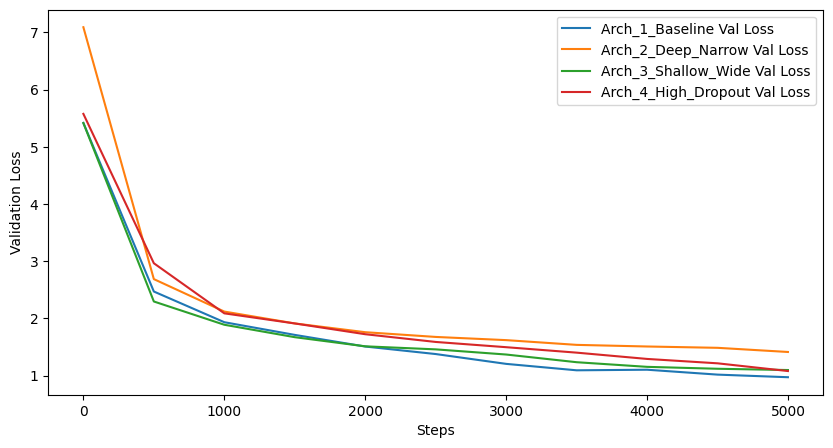

In [2]:
import json
import matplotlib.pyplot as plt

data = json.load(open('output/architecture_comparison_stats.json'))

plt.figure(figsize=(10, 5))
for name, stats in data.items():
    plt.plot(stats['step'], stats['val_loss'], label=f"{name} Val Loss")

plt.xlabel("Steps")
plt.ylabel("Validation Loss")
plt.legend()
plt.savefig("val_loss_comparison.png")
print("✅ Saved comparison graph as val_loss_comparison.png")

In [ ]:
# A simple way to load any model you want to generate stories from
model_name = "Arch_1_Baseline" # Change this to load different architectures
final_model = GPT(arch_configs[model_name]).to(device)
final_model.load_state_dict(torch.load(f'output/{model_name}_weights.pt'))
final_model.eval()

print(f"📝 Generating stories from {model_name}...")

NameError: name 'arch_configs' is not defined

: 